In [91]:
import pandas as pd 
import numpy as np 
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

In [92]:
df = pd.read_csv("credit_risk_cleaned.csv")
print(df.shape)

(51336, 88)


In [93]:
# df.groupby("EDUCATION")["Approved_Flag"].value_counts(normalize=True)

In [94]:
df.info

<bound method DataFrame.info of        PROSPECTID  Total_TL  Tot_Closed_TL  Tot_Active_TL  \
0               1         5              4              1   
1               2         1              0              1   
2               3         8              0              8   
3               4         1              0              1   
4               5         3              2              1   
...           ...       ...            ...            ...   
51331       51332         3              0              3   
51332       51333         4              2              2   
51333       51334         2              1              1   
51334       51335         2              1              1   
51335       51336         1              0              1   

       Total_TL_opened_L6M  Tot_TL_closed_L6M  pct_tl_open_L6M  \
0                        0                  0            0.000   
1                        0                  0            0.000   
2                        1           

In [95]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PROSPECTID,51336.0,NaN,NaN,NaN,25668.5,14819.571046,1.0,12834.75,25668.5,38502.25,51336.0
Total_TL,51336.0,NaN,NaN,NaN,4.858598,7.177116,1.0,1.0,2.0,5.0,235.0
Tot_Closed_TL,51336.0,NaN,NaN,NaN,2.770415,5.94168,0.0,0.0,1.0,3.0,216.0
Tot_Active_TL,51336.0,NaN,NaN,NaN,2.088184,2.290774,0.0,1.0,1.0,3.0,47.0
Total_TL_opened_L6M,51336.0,NaN,NaN,NaN,0.736754,1.296717,0.0,0.0,0.0,1.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...
last_prod_enq2,51336,6,others,20831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_prod_enq2,51336,6,others,28120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit_Score,51336.0,NaN,NaN,NaN,679.859222,20.502764,469.0,669.0,680.0,691.0,811.0
Approved_Flag,51336,4,P2,32199,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
# Create contingency table
contingency_table = pd.crosstab(
    df["EDUCATION"],
    df["Approved_Flag"]
)

print(contingency_table)

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p:.10f}")

# Interpretation
alpha = 0.05
# H0: Education level has no association with credit approval category.
# H1: Education level is associated with credit approval category
if p < alpha:
    print("\nReject the Null Hypothesis (H₀)")
    print("Education and Credit Approval are significantly associated.")
else:
    print("\nFail to Reject the Null Hypothesis (H₀)")
    print("No significant association found.")

Approved_Flag     P1     P2    P3    P4
EDUCATION                              
12TH            1430   9347  2196  1494
GRADUATE        1994  10086  2433  2160
OTHERS           381   1878   379   279
POST-GRADUATE    348   1353   289   252
PROFESSIONAL      52    160    41    16
SSC              982   6014  1305   975
UNDER GRADUATE   616   3361   809   706

Chi-Square Statistic : 225.2461
Degrees of Freedom   : 18
P-value              : 0.0000000000

Reject the Null Hypothesis (H₀)
Education and Credit Approval are significantly associated.


In [97]:
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Cramér's V: {cramers_v:.4f}")

if cramers_v < 0.10:
    strength = "Negligible"
elif cramers_v < 0.30:
    strength = "Weak"
elif cramers_v < 0.50:
    strength = "Moderate"
else:
    strength = "Strong"

print(f"Association Strength: {strength}")

Cramér's V: 0.0382
Association Strength: Negligible


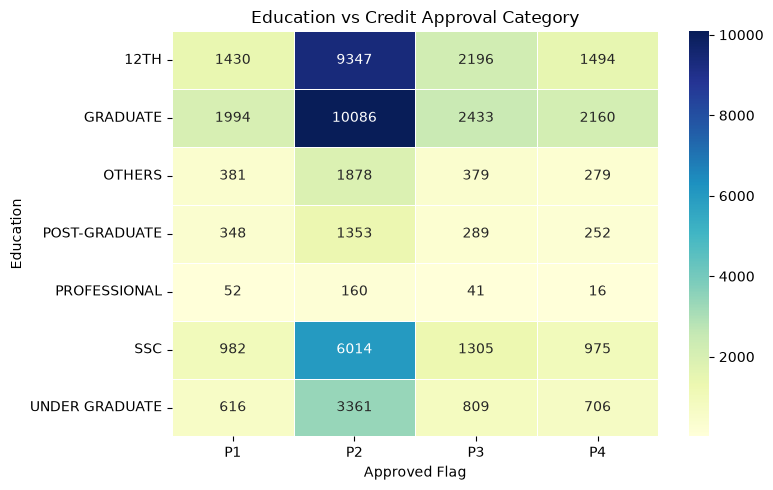

In [98]:
# Create contingency table
contingency_table = pd.crosstab(
    df["EDUCATION"],
    df["Approved_Flag"]
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    contingency_table,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Education vs Credit Approval Category")
plt.xlabel("Approved Flag")
plt.ylabel("Education")
plt.tight_layout()

plt.show()

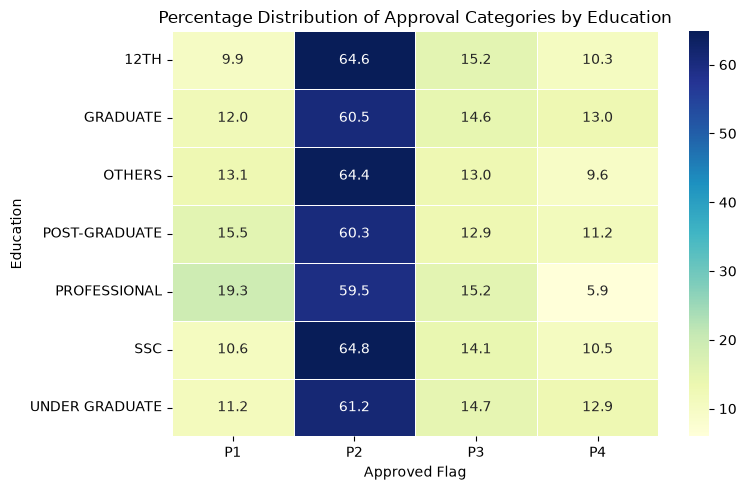

In [99]:
# Convert counts to row percentages
percentage_table = contingency_table.div(
    contingency_table.sum(axis=1),
    axis=0
) * 100

plt.figure(figsize=(8, 5))

sns.heatmap(
    percentage_table,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Percentage Distribution of Approval Categories by Education")
plt.xlabel("Approved Flag")
plt.ylabel("Education")
plt.tight_layout()

plt.show()

In [100]:
# Create a copy for model preparation
df_model = df.copy()

print(df_model.shape)

(51336, 88)


In [101]:
categorical_cols = [
    "MARITALSTATUS",
    "EDUCATION",
    "GENDER",
    "last_prod_enq2",
    "first_prod_enq2"
]

print(df_model[categorical_cols].head())

  MARITALSTATUS      EDUCATION GENDER last_prod_enq2 first_prod_enq2
0       Married           12TH      M             PL              PL
1        Single       GRADUATE      F   ConsumerLoan    ConsumerLoan
2       Married            SSC      M   ConsumerLoan          others
3       Married            SSC      M         others          others
4       Married  POST-GRADUATE      M             AL              AL


In [102]:
gender_mapping = { #we're mapping the binary variables 
    "M": 1,
    "F": 0
}

marital_mapping = {
    "Married": 1,
    "Single": 0
}

In [103]:
df_model["GENDER"] = df_model["GENDER"].map(gender_mapping)

df_model["MARITALSTATUS"] = df_model["MARITALSTATUS"].map(marital_mapping)

### One-Hot Encoding

The remaining categorical variables are converted into numerical features using one-hot encoding.

One-hot encoding was chosen because it allows the model to treat each category independently without assuming a numerical relationship between categories. Although Education exhibits a weak association with credit approval, Cramér's V indicated a negligible effect size. Therefore, one-hot encoding was retained as the baseline encoding strategy while avoiding unnecessary assumptions about the spacing between education levels.

In [104]:
df_model = pd.get_dummies(
    df_model,
    columns=[
        "EDUCATION",
        "last_prod_enq2",
        "first_prod_enq2"
    ],
    dtype=int
)

In [105]:
print(df_model.shape)

df_model.head()

(51336, 104)


,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,first_prod_enq2_AL,first_prod_enq2_CC,first_prod_enq2_ConsumerLoan,first_prod_enq2_HL,first_prod_enq2_PL,first_prod_enq2_others
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0,0,1,0,0,0,0,0,1,0
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,1,0,0,0,0,0,1,0,0,0
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,1,0,0,0,0,0,0,0,0,1
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0,0,0,1,0,0,0,0,0,1
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0,0,0,0,1,0,0,0,0,0


In [106]:
encoded_columns = [
    col for col in df_model.columns
    if "EDUCATION_" in col
    or "last_prod_enq2_" in col
    or "first_prod_enq2_" in col
]

print(encoded_columns)

['EDUCATION_12TH', 'EDUCATION_GRADUATE', 'EDUCATION_OTHERS', 'EDUCATION_POST-GRADUATE', 'EDUCATION_PROFESSIONAL', 'EDUCATION_SSC', 'EDUCATION_UNDER GRADUATE', 'last_prod_enq2_AL', 'last_prod_enq2_CC', 'last_prod_enq2_ConsumerLoan', 'last_prod_enq2_HL', 'last_prod_enq2_PL', 'last_prod_enq2_others', 'first_prod_enq2_AL', 'first_prod_enq2_CC', 'first_prod_enq2_ConsumerLoan', 'first_prod_enq2_HL', 'first_prod_enq2_PL', 'first_prod_enq2_others']


### Future Experiment

Education was one-hot encoded for the baseline model.

Since exploratory analysis suggested a weak but ordered relationship between education level and approval category, an alternative model using ordinal encoding will also be evaluated later. The same Random Forest model and evaluation metrics will be used to compare both encoding strategies.

In [107]:
target_mapping = { #Original order of approved categories is maintained
    "P1": 0,
    "P2": 1,
    "P3": 2,
    "P4": 3
}

df_model["Approved_Flag"] = df_model["Approved_Flag"].map(target_mapping)

In [108]:
df_model["Approved_Flag"].value_counts().sort_index()

Approved_Flag
0     5803
1    32199
2     7452
3     5882
Name: count, dtype: int64

In [109]:
X = df_model.drop(columns=["Approved_Flag"])
y = df_model["Approved_Flag"]

print(X.shape)
print(y.shape)

(51336, 103)
(51336,)


In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [111]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(41068, 103)
(10268, 103)
(41068,)
(10268,)


### Train-Test Split

The dataset is split into training (80%) and testing (20%) subsets.

Stratified sampling is used to preserve the class distribution of the target variable in both sets. This is particularly important because the approval categories are imbalanced, with P2 representing the majority class.

In [112]:
print(y_train.value_counts(normalize=True).sort_index())

print()

print(y_test.value_counts(normalize=True).sort_index())

Approved_Flag
0    0.113032
1    0.627228
2    0.145150
3    0.114590
Name: proportion, dtype: float64

Approved_Flag
0    0.113070
1    0.627191
2    0.145208
3    0.114531
Name: proportion, dtype: float64


In [113]:
constant_cols = [
    col
    for col in X_train.columns
    if X_train[col].nunique() == 1
]

print(f"Number of constant features: {len(constant_cols)}")
print(constant_cols)

Number of constant features: 0
[]


### Constant Feature Analysis

Constant features contain the same value for every observation and therefore provide no information for distinguishing between different customers.

The training dataset was examined for constant features before feature selection.

No constant features were found, indicating that every feature exhibits some variability across the dataset. Therefore, no features were removed at this stage.

In [114]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.80:
            high_corr_pairs.append((row, col, upper.loc[row, col]))

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: x[2], reverse=True)

print(f"Highly correlated feature pairs: {len(high_corr_pairs)}")

for pair in high_corr_pairs:
    print(pair)

Highly correlated feature pairs: 38
('pct_active_tl', 'pct_of_active_TLs_ever', np.float64(1.0))
('pct_active_tl', 'pct_closed_tl', np.float64(0.9999999999999996))
('pct_closed_tl', 'pct_of_active_TLs_ever', np.float64(0.9999999999999996))
('Age_Oldest_TL', 'Age_Newest_TL', np.float64(0.9998699910192074))
('pct_PL_enq_L6m_of_L12m', 'pct_PL_enq_L6m_of_ever', np.float64(0.9655098939697677))
('pct_CC_enq_L6m_of_L12m', 'pct_CC_enq_L6m_of_ever', np.float64(0.9608062477465471))
('num_std_6mts', 'num_std_12mts', np.float64(0.9571134202721093))
('Total_TL', 'Tot_Closed_TL', np.float64(0.956672048404394))
('pct_currentBal_all_TL', 'CC_utilization', np.float64(0.9549137926061801))
('num_lss_6mts', 'num_lss_12mts', np.float64(0.9430272046963591))
('num_dbt_6mts', 'num_dbt_12mts', np.float64(0.9352857511970939))
('Gold_TL', 'Secured_TL', np.float64(0.9316282862426701))
('Tot_Closed_TL', 'Secured_TL', np.float64(0.9310146338307362))
('enq_L12m', 'enq_L6m', np.float64(0.9239432798921593))
('num_time

In [115]:
(
    X_train["pct_active_tl"] ==
    X_train["pct_of_active_TLs_ever"]
).all()

np.True_

In [116]:
(
    X_train["pct_closed_tl"] ==
    X_train["pct_of_active_TLs_ever"]
).all()

np.False_

### Duplicate Feature Detection

Correlation analysis identified a perfect correlation (1.0) between `pct_active_tl` and `pct_of_active_TLs_ever`.

A row-wise equality check confirmed that both columns contain identical values for every observation.

Since `pct_of_active_TLs_ever` does not provide any additional information, it was removed to eliminate redundancy while preserving all information contained in the dataset.

In [117]:
(
    X_train["Age_Oldest_TL"] ==
    X_train["Age_Newest_TL"]
).all()

np.False_

In [118]:
age_diff = (
    X_train["Age_Oldest_TL"] -
    X_train["Age_Newest_TL"]
)

print(age_diff.describe())

print("\nTop 10 largest differences:\n")

X_train.loc[
    age_diff.nlargest(10).index,
    ["Age_Oldest_TL", "Age_Newest_TL"]
]

count    41068.000000
mean        29.432161
std         39.800867
min          0.000000
25%          0.000000
50%         13.000000
75%         45.000000
max        382.000000
dtype: float64

Top 10 largest differences:



,Age_Oldest_TL,Age_Newest_TL
5093,385,3
39126,373,26
13439,352,10
21867,355,29
12364,324,2
50788,337,18
25201,333,33
44903,301,4
14227,302,10
3797,299,9


In [119]:
(
    X_train["Gold_TL"] ==
    X_train["Secured_TL"]
).all()

np.False_

In [120]:
(
    X_train["pct_currentBal_all_TL"] ==
    X_train["CC_utilization"]
).all()

np.False_

In [121]:
(
    X_train["max_recent_level_of_deliq"] ==
    X_train["recent_level_of_deliq"]
).all()

np.False_

In [122]:
(
    X_train[["Gold_TL", "Secured_TL"]]
    .assign(diff=X_train["Secured_TL"] - X_train["Gold_TL"])
    .sort_values("diff", ascending=False)
    .head(10)
)

,Gold_TL,Secured_TL,diff
10335,0,93,93
30295,20,87,67
18139,38,98,60
46729,19,76,57
43640,12,54,42
31273,2,43,41
28576,5,46,41
5227,0,39,39
10864,5,44,39
50937,20,58,38


In [123]:
(
    X_train[["pct_currentBal_all_TL", "CC_utilization"]]
    .assign(diff=np.abs(
        X_train["pct_currentBal_all_TL"] -
        X_train["CC_utilization"]
    ))
    .sort_values("diff", ascending=False)
    .head(10)
)

,pct_currentBal_all_TL,CC_utilization,diff
19830,0.913,8.297,7.384
5998,0.757,4.103,3.346
29491,0.985,3.927,2.942
9827,2.757,5.516,2.759
38011,0.468,2.973,2.505
23626,1.876,0.000,1.876
35014,0.301,2.025,1.724
16741,1.143,2.628,1.485
41707,0.794,2.269,1.475
16222,0.730,2.128,1.398


In [124]:
(
    X_train[["max_recent_level_of_deliq",
             "recent_level_of_deliq"]]
    .assign(diff=np.abs(
        X_train["max_recent_level_of_deliq"] -
        X_train["recent_level_of_deliq"]
    ))
    .sort_values("diff", ascending=False)
    .head(10)
)

,max_recent_level_of_deliq,recent_level_of_deliq,diff
23244,900,1,899
16743,900,4,896
39336,900,7,893
30403,900,8,892
50783,900,10,890
35748,900,17,883
894,900,25,875
45994,900,25,875
48264,900,26,874
19398,900,28,872


In [126]:
missing = X_train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

CC_utilization                  38148
PL_utilization                  35591
time_since_first_deliquency     28811
time_since_recent_deliquency    28811
max_delinquency_level           28811
max_unsec_exposure_inPct        18614
max_deliq_6mts                  10331
max_deliq_12mts                  8684
PL_enq_L6m                       5035
CC_enq_L6m                       5035
tot_enq                          5035
CC_enq                           5035
enq_L6m                          5035
PL_enq                           5035
CC_enq_L12m                      5035
PL_enq_L12m                      5035
time_since_recent_enq            5035
enq_L12m                         5035
enq_L3m                          5035
time_since_recent_payment        3471
dtype: int64

In [127]:
X_train.isna().sum().sum()

np.int64(256657)

In [128]:
missing_percent = (
    X_train.isna()
           .mean()
           .mul(100)
           .sort_values(ascending=False)
)

missing_percent

CC_utilization                  92.889841
PL_utilization                  86.663582
time_since_recent_deliquency    70.154378
time_since_first_deliquency     70.154378
max_delinquency_level           70.154378
                                  ...    
first_prod_enq2_CC               0.000000
first_prod_enq2_ConsumerLoan     0.000000
first_prod_enq2_HL               0.000000
first_prod_enq2_PL               0.000000
first_prod_enq2_others           0.000000
Length: 103, dtype: float64

Missing Value Strategy

The dataset contains a substantial number of missing values. However, these missing values are not assumed to be random. Based on the feature descriptions and domain understanding, many missing values represent situations where a financial event never occurred (e.g., no credit card, no personal loan, or no delinquency history). Therefore, missing values will be handled according to their business meaning rather than using generic statistical imputation.

In [125]:
mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = (
    pd.Series(mi_scores, index=X_train.columns)
      .sort_values(ascending=False)
)

mi_scores.head(20)

ValueError: Input X contains NaN.

In [ ]:
model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [ ]:
print(LogisticRegression)

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [ ]:
import sklearn
print(sklearn.__version__)
print(LogisticRegression)

1.9.0
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [ ]:
X_train.dtypes

NameError: name 'X_train' is not defined

In [ ]:
# df.isna().sum().sort_values(ascending = False)

In [ ]:
# Gender, Marital Status, Education are categorical variables. 
# We will convert them to numerical variables using encoding.

# last_prod_enq2 = Lates product enquired for 
# first_prod_enq2 = First productd enquired for

# ^ These are also categorical variables. We will convert them to numerical variables using encoding.

In [ ]:
# categorical_cols = df.select_dtypes(include=["object"]).columns

# numerical_cols = df.select_dtypes(exclude=["object"]).columns

# print("Categorical Columns:")
# print(categorical_cols.tolist())

# print("\nNumber of categorical columns:", len(categorical_cols))

# print("\nNumerical Columns:", len(numerical_cols))

In [ ]:
# categorical_cols = [
#     "MARITALSTATUS",
#     "EDUCATION",
#     "GENDER",
#     "last_prod_enq2",
#     "first_prod_enq2"
# ]

# for col in categorical_cols:
#     print("=" * 50)
#     print(col)
#     print(df[col].value_counts())

In [ ]:
# df["GENDER"] = df["GENDER"].map({
#     "M": 1,
#     "F": 0
# })

# df["MARITALSTATUS"] = df["MARITALSTATUS"].map({
#     "Married": 1,
#     "Single": 0
# })

In [ ]:
# df["EDUCATION"].value_counts()

In [ ]:
# df = pd.get_dummies( #one-hot encoding 
#     df,
#     columns=[
#         "EDUCATION",
#         "last_prod_enq2",
#         "first_prod_enq2"
#     ],
#     drop_first=True,
#     dtype=int
# # )

In [ ]:
# target_mapping = {
#     "P1": 0,
#     "P2": 1,
#     "P3": 2,
#     "P4": 3
# }

# df["Approved_Flag"] = df["Approved_Flag"].map(target_mapping)

In [ ]:
# # print(df.shape)

# print("\nRemaining categorical columns:")
# print(df.select_dtypes(include="object").columns.tolist())

## Train-Test Split

The dataset is split into training (80%) and testing (20%) sets. We use stratified sampling to preserve the distribution of the target classes (`Approved_Flag`) in both subsets. Feature selection and model training will be performed only on the training set to prevent data leakage.

## Feature Engineering Summary 😼😼

The following feature engineering steps were completed:

- Encoded categorical variables using One-Hot Encoding.
- Converted target labels (P1–P4) into numerical classes.
- Split the data into training and testing sets.
- Removed identifier columns (PROSPECTID).
- Removed near-zero variance features.
- Removed highly correlated features to reduce redundancy.
- Evaluated feature importance using:
    - Mutual Information
    - Random Forest Feature Importance

The processed dataset is now ready for model building.